This notebook contains code to generate parameter fits and predicted Q-values for the HMM model

There are two included models:
1. Turn Bias
2. Spatial Bias

The likelihood function is as follows:


Assuming we're at stem 1,
```
QEff1 = βstay * Q(OppositeLeaf) + stay_bias
QEff2 = βgo * QAvg(stem) + spatial_bias[2]
QEff3 = βgo * QAvg(stem)
```
Our stem choice is then predicted by a softmax: $p(a) = \frac{\exp{p(a)}}{\sum_{a'}\exp{p(a')}}$

In the Turn Bias model, all spatial biases are modeled by a single `turn_bias` parameter
In the Spatial Bias model, each stem has a unique spatial bias


In [1]:
# Whether to recompute results
#RERUN = false;
RERUN = true;

In [2]:
# Save Q-values and other meta-information
SAVE_Q = true;

In [3]:
using SpecialFunctions
using Plots
using StatsPlots
using FileIO
using EM
filepath = ".."
include("$(filepath)/code/qlearner.jl")
include("$(filepath)/code/util.jl")
include("$(filepath)/code/em_scripts.jl");

# Turn Bias

In [4]:
function find_Q_vals_by_day(animal, results; add_leaf=true, rewscaled=true)
    data = load_animal(animal, "..")
    ndays = maximum(data.daynum)
    liks = zeros(ndays)
    dfs = []
    for i in 1:ndays
        (liks[i], df) = qlik(view(data, data.daynum .== i, :), results;
            subject=i, add_leaf=add_leaf, rewscaled=rewscaled, record=true)
        push!(dfs, df)
    end
    # Combine all session results
    record_df = vcat(dfs...)
    # Append columns to the original data
    hcat(data, record_df)
end;

In [5]:
results = Dict()
Qs = Dict();

# Model Fits

In [15]:
fn = run_q_leaf_initialQ_stay_turn_leafspatial_γ2
fnname = "leaf_initialQ_stay_turn_leafspatial_γ2_rewscaled"
println("Model: $(fn)")

Model: run_q_leaf_initialQ_stay_turn_leafspatial_γ2


In [16]:
animal = "peanut"
if RERUN
    #results[animal] = fn(load_animal(animal); maxiter=100, extended=true) #AC changing to add extra arg to load animal july 22 bc copying hmm results syntax
    results[animal] = fn(load_animal(animal, ".."); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/qlearner.jl:397


Turn Bias: peanut
AIC: 3452.28


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ γ2    initi α     <br/> 2.99  5.93  2.01  1.69  <span style='color: red'>-0.77</span>  0.09  0.17  0.24  <span style='color: red'>-0.81</span>  1.34  <span style='color: red'>-0.1</span><br/>p:<br/> 0.01  0.01  0.01  0.01  0.02  NaN  0.83  0.72  0.01  0.05  0.59</pre>σ²:<br/><pre>  2.9    1.1   <span style='color: red'>-2.91</span>   0.71  <span style='color: red'>-0.84</span>   0.91   2.58   2.55   0.43   2.62   0.42<br/>  1.1    1.16  <span style='color: red'>-0.58</span>   0.02  <span style='color: red'>-0.85</span>   0.01   0.42   0.12   0.15   0.14   0.03<br/> <span style='color: red'>-2.91</span>  <span style='color: red'>-0.58</span>   3.65  <span style='color: red'>-0.95</span>   0.37  <span style='color: red'>-1.5</span>   <span style='color: red'>-3.29</span>  <span style='color: red'>-3.68</span>  <span style='color: red'>-0.44</span>  <span style='color: red'>-3.57</span>  <span style='color: red'>-0.57</span><br/>  0.71   0.02  <span style='color: red'>-0.95</span>   0.33   0.01   0.37   0.79   0.88   0.17   1.17   0.22<br/> <span style='color: red'>-0.84</span>  <span style='color: red'>-0.85</span>   0.37   0.01   0.68   0.14  <span style='color: red'>-0.07</span>   0.19  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.06</span><br/>  0.91   0.01  <span style='color: red'>-1.5</span>    0.37   0.14   1.06   2.18   2.53  <span style='color: red'>-0.02</span>   1.16  <span style='color: red'>-0.03</span><br/>  2.58   0.42  <span style='color: red'>-3.29</span>   0.79  <span style='color: red'>-0.07</span>   2.18   5.5    5.88  <span style='color: red'>-0.12</span>   2.04  <span style='color: red'>-0.33</span><br/>  2.55   0.12  <span style='color: red'>-3.68</span>   0.88   0.19   2.53   5.88   6.54  <span style='color: red'>-0.14</span>   2.47  <span style='color: red'>-0.27</span><br/>  0.43   0.15  <span style='color: red'>-0.44</span>   0.17  <span style='color: red'>-0.13</span>  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.12</span>  <span style='color: red'>-0.14</span>   0.2    0.77   0.27<br/>  2.62   0.14  <span style='color: red'>-3.57</span>   1.17  <span style='color: red'>-0.06</span>   1.16   2.04   2.47   0.77   4.68   1.1<br/>  0.42   0.03  <span style='color: red'>-0.57</span>   0.22  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.03</span>  <span style='color: red'>-0.33</span>  <span style='color: red'>-0.27</span>   0.27   1.1    0.41</pre>")

In [17]:
animal = "senor"
if RERUN
    results[animal] = fn(load_animal(animal, ".."); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/qlearner.jl:397


Turn Bias: senor
AIC: 3162.31


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ γ2    initi α     <br/> 2.32  6.4  1.8  2.15  <span style='color: red'>-0.25</span>  <span style='color: red'>-0.66</span>  <span style='color: red'>-1.52</span>  0.62  <span style='color: red'>-0.55</span>  1.25  <span style='color: red'>-0.2</span><br/>p:<br/> 0.01  0.01  0.01  0.01  0.47  0.06  0.03  0.02  0.01  0.04  0.21</pre>σ²:<br/><pre>  5.36   1.08   0.07   0.83  <span style='color: red'>-2.16</span>  <span style='color: red'>-2.4</span>   <span style='color: red'>-1.32</span>  <span style='color: red'>-0.71</span>   0.49   4.15   0.75<br/>  1.08   0.97   0.9    0.12  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.06</span>  <span style='color: red'>-0.76</span>   0.18   0.17   0.16  <span style='color: red'>-0.08</span><br/>  0.07   0.9    1.76  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.1</span>    0.4   <span style='color: red'>-1.49</span>   0.9    0.12  <span style='color: red'>-0.91</span>  <span style='color: red'>-0.16</span><br/>  0.83   0.12  <span style='color: red'>-0.04</span>   0.18  <span style='color: red'>-0.27</span>  <span style='color: red'>-0.3</span>   <span style='color: red'>-0.07</span>  <span style='color: red'>-0.08</span>   0.05   0.76   0.15<br/> <span style='color: red'>-2.16</span>  <span style='color: red'>-0.35</span>  <span style='color: red'>-0.1</span>   <span style='color: red'>-0.27</span>   1.16   1.11   0.75   0.21  <span style='color: red'>-0.21</span>  <span style='color: red'>-1.49</span>  <span style='color: red'>-0.32</span><br/> <span style='color: red'>-2.4</span>   <span style='color: red'>-0.06</span>   0.4   <span style='color: red'>-0.3</span>    1.11   1.64   1.04   0.5   <span style='color: red'>-0.23</span>  <span style='color: red'>-2.13</span>  <span style='color: red'>-0.51</span><br/> <span style='color: red'>-1.32</span>  <span style='color: red'>-0.76</span>  <span style='color: red'>-1.49</span>  <span style='color: red'>-0.07</span>   0.75   1.04   3.85  <span style='color: red'>-0.73</span>  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.18</span>  <span style='color: red'>-0.31</span><br/> <span style='color: red'>-0.71</span>   0.18   0.9   <span style='color: red'>-0.08</span>   0.21   0.5   <span style='color: red'>-0.73</span>   0.69  <span style='color: red'>-0.04</span>  <span style='color: red'>-0.93</span>  <span style='color: red'>-0.1</span><br/>  0.49   0.17   0.12   0.05  <span style='color: red'>-0.21</span>  <span style='color: red'>-0.23</span>  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.04</span>   0.06   0.29   0.05<br/>  4.15   0.16  <span style='color: red'>-0.91</span>   0.76  <span style='color: red'>-1.49</span>  <span style='color: red'>-2.13</span>  <span style='color: red'>-0.18</span>  <span style='color: red'>-0.93</span>   0.29   4.12   0.81<br/>  0.75  <span style='color: red'>-0.08</span>  <span style='color: red'>-0.16</span>   0.15  <span style='color: red'>-0.32</span>  <span style='color: red'>-0.51</span>  <span style='color: red'>-0.31</span>  <span style='color: red'>-0.1</span>    0.05   0.81   0.22</pre>")

In [18]:
animal = "chimi"
if RERUN
    results[animal] = fn(load_animal(animal, ".."); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/qlearner.jl:397


Turn Bias: chimi
AIC: 1893.91


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ γ2    initi α     <br/> <span style='color: red'>-1.45</span>  7.89  1.91  1.84  <span style='color: red'>-0.24</span>  0.0  <span style='color: red'>-0.04</span>  0.35  <span style='color: red'>-0.7</span>  <span style='color: red'>-1.11</span>  <span style='color: red'>-0.86</span><br/>p:<br/> 0.31  0.01  0.01  0.01  0.35  0.99  NaN  0.21  0.01  0.05  0.01</pre>σ²:<br/><pre>  23.67  <span style='color: red'>-8.26</span>  <span style='color: red'>-10.13</span>   3.16   2.91  <span style='color: red'>-0.55</span>   0.66   1.04   1.47  11.15   2.9<br/>  <span style='color: red'>-8.26</span>   3.62    2.66  <span style='color: red'>-1.09</span>  <span style='color: red'>-0.81</span>   0.35  <span style='color: red'>-0.25</span>  <span style='color: red'>-0.94</span>  <span style='color: red'>-0.38</span>  <span style='color: red'>-4.18</span>  <span style='color: red'>-1.08</span><br/> <span style='color: red'>-10.13</span>   2.66   19.52  <span style='color: red'>-2.01</span>  <span style='color: red'>-2.9</span>   <span style='color: red'>-1.76</span>  <span style='color: red'>-1.47</span>   4.17  <span style='color: red'>-1.42</span>  <span style='color: red'>-2.26</span>  <span style='color: red'>-1.23</span><br/>   3.16  <span style='color: red'>-1.09</span>   <span style='color: red'>-2.01</span>   0.81   0.34  <span style='color: red'>-0.1</span>    0.13   0.03   0.23   1.6    0.42<br/>   2.91  <span style='color: red'>-0.81</span>   <span style='color: red'>-2.9</span>    0.34   0.78   0.16   0.19  <span style='color: red'>-0.37</span>   0.25   0.94   0.28<br/>  <span style='color: red'>-0.55</span>   0.35   <span style='color: red'>-1.76</span>  <span style='color: red'>-0.1</span>    0.16   0.32   0.14  <span style='color: red'>-0.72</span>   0.08  <span style='color: red'>-0.65</span>  <span style='color: red'>-0.07</span><br/>   0.66  <span style='color: red'>-0.25</span>   <span style='color: red'>-1.47</span>   0.13   0.19   0.14   0.13  <span style='color: red'>-0.29</span>   0.09   0.12   0.09<br/>   1.04  <span style='color: red'>-0.94</span>    4.17   0.03  <span style='color: red'>-0.37</span>  <span style='color: red'>-0.72</span>  <span style='color: red'>-0.29</span>   1.78  <span style='color: red'>-0.24</span>   1.32   0.13<br/>   1.47  <span style='color: red'>-0.38</span>   <span style='color: red'>-1.42</span>   0.23   0.25   0.08   0.09  <span style='color: red'>-0.24</span>   0.15   0.55   0.18<br/>  11.15  <span style='color: red'>-4.18</span>   <span style='color: red'>-2.26</span>   1.6    0.94  <span style='color: red'>-0.65</span>   0.12   1.32   0.55   5.89   1.43<br/>   2.9   <span style='color: red'>-1.08</span>   <span style='color: red'>-1.23</span>   0.42   0.28  <span style='color: red'>-0.07</span>   0.09   0.13   0.18   1.43   0.39</pre>")

In [19]:
animal = "j16"
if RERUN
    results[animal] = fn(load_animal(animal, ".."); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/qlearner.jl:397


Turn Bias: j16
AIC: 2434.99


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ γ2    initi α     <br/> 2.78  7.16  1.11  2.14  <span style='color: red'>-0.14</span>  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.06</span>  0.33  <span style='color: red'>-0.49</span>  0.63  <span style='color: red'>-0.17</span><br/>p:<br/> 0.01  0.01  0.17  0.01  0.51  0.36  0.55  0.41  NaN  0.26  0.07</pre>σ²:<br/><pre>  3.87   0.05   2.03   1.47   0.1   <span style='color: red'>-0.93</span>  <span style='color: red'>-0.06</span>   1.14   0.11   3.13   0.5<br/>  0.05   0.18  <span style='color: red'>-0.19</span>  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.05</span>   0.16   0.03  <span style='color: red'>-0.25</span>   0.01  <span style='color: red'>-0.11</span>  <span style='color: red'>-0.04</span><br/>  2.03  <span style='color: red'>-0.19</span>   4.78   0.09  <span style='color: red'>-0.55</span>  <span style='color: red'>-1.69</span>   0.08   2.13  <span style='color: red'>-0.1</span>    1.23   0.07<br/>  1.47  <span style='color: red'>-0.17</span>   0.09   1.25   0.36  <span style='color: red'>-0.26</span>  <span style='color: red'>-0.05</span>   0.55   0.07   1.55   0.34<br/>  0.1   <span style='color: red'>-0.05</span>  <span style='color: red'>-0.55</span>   0.36   0.18   0.12  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.07</span>   0.03   0.26   0.09<br/> <span style='color: red'>-0.93</span>   0.16  <span style='color: red'>-1.69</span>  <span style='color: red'>-0.26</span>   0.12   0.68  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.87</span>   0.02  <span style='color: red'>-0.73</span>  <span style='color: red'>-0.09</span><br/> <span style='color: red'>-0.06</span>   0.03   0.08  <span style='color: red'>-0.05</span>  <span style='color: red'>-0.02</span>  <span style='color: red'>-0.0</span>    0.06  <span style='color: red'>-0.0</span>   <span style='color: red'>-0.01</span>  <span style='color: red'>-0.1</span>   <span style='color: red'>-0.03</span><br/>  1.14  <span style='color: red'>-0.25</span>   2.13   0.55  <span style='color: red'>-0.07</span>  <span style='color: red'>-0.87</span>  <span style='color: red'>-0.0</span>    1.27  <span style='color: red'>-0.03</span>   0.97   0.16<br/>  0.11   0.01  <span style='color: red'>-0.1</span>    0.07   0.03   0.02  <span style='color: red'>-0.01</span>  <span style='color: red'>-0.03</span>   0.01   0.11   0.02<br/>  3.13  <span style='color: red'>-0.11</span>   1.23   1.55   0.26  <span style='color: red'>-0.73</span>  <span style='color: red'>-0.1</span>    0.97   0.11   2.78   0.49<br/>  0.5   <span style='color: red'>-0.04</span>   0.07   0.34   0.09  <span style='color: red'>-0.09</span>  <span style='color: red'>-0.03</span>   0.16   0.02   0.49   0.1</pre>")

In [20]:
animal = "wilbur"
if RERUN
    results[animal] = fn(load_animal(animal, ".."); maxiter=100, extended=true)
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])    
    save("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "results", results[animal])
else
    results[animal] = load("$(filepath)/results/q_biases/q_$(fnname)_$(animal).jld2", "q_$(fnname)_$(animal)")
    Qs[animal] = find_Q_vals_by_day(animal, results[animal])
end
if SAVE_Q
    CSV.write("$(filepath)/results/qlearner_q_vals/qlearner_q_vals_$(fnname)_$(animal).csv", Qs[animal])
end
println("Turn Bias: $(animal)")
println("AIC: $(round(iaic(results[animal]); digits=2))")
transforms = [["volatility", x->0.5+0.5*erf(x / sqrt(2))]]
HTML(show_results(results[animal], transforms=transforms))

┌ Info: Running emerrors
└ @ Main /home/alison/Src/SpatialBanditTask/code/qlearner.jl:397


Turn Bias: wilbur
AIC: 2659.09


HTML{String}("<pre>[\"βgo\", \"βstay\", \"βleaf\", \"stay_bias\", \"turn_bias\", \"leaf_spatial_1\", \"leaf_spatial_2\", \"leaf_spatial_3\", \"γ2\", \"initial_Q\", \"α\"]<br/></pre>β:<br/><pre> βgo   βstay βleaf stay_ turn_ leaf_ leaf_ leaf_ γ2    initi α     <br/> 2.72  6.85  1.96  1.84  <span style='color: red'>-0.66</span>  0.38  0.51  0.43  <span style='color: red'>-0.66</span>  1.42  <span style='color: red'>-0.3</span><br/>p:<br/> 0.01  0.01  0.01  0.01  0.01  0.15  0.28  0.03  0.01  0.01  0.05</pre>σ²:<br/><pre>  5.88   1.23  <span style='color: red'>-2.95</span>   1.54   0.11   0.47  <span style='color: red'>-0.3</span>    0.26   1.09   3.59   0.87<br/>  1.23   4.28   2.25  <span style='color: red'>-0.91</span>  <span style='color: red'>-0.47</span>   0.02   0.22   0.36   0.12   0.26   0.05<br/> <span style='color: red'>-2.95</span>   2.25   4.55  <span style='color: red'>-1.64</span>  <span style='color: red'>-0.8</span>    0.22   0.72   0.36  <span style='color: red'>-0.59</span>  <span style='color: red'>-1.7</span>   <span style='color: red'>-0.43</span><br/>  1.54  <span style='color: red'>-0.91</span>  <span style='color: red'>-1.64</span>   0.78   0.17   0.14  <span style='color: red'>-0.17</span>  <span style='color: red'>-0.03</span>   0.31   1.09   0.27<br/>  0.11  <span style='color: red'>-0.47</span>  <span style='color: red'>-0.8</span>    0.17   0.32  <span style='color: red'>-0.04</span>   0.09   0.05   0.04   0.01   0.03<br/>  0.47   0.02   0.22   0.14  <span style='color: red'>-0.04</span>   0.51   0.57   0.43   0.13   0.63   0.19<br/> <span style='color: red'>-0.3</span>    0.22   0.72  <span style='color: red'>-0.17</span>   0.09   0.57   0.96   0.64  <span style='color: red'>-0.0</span>    0.14   0.11<br/>  0.26   0.36   0.36  <span style='color: red'>-0.03</span>   0.05   0.43   0.64   0.47   0.08   0.37   0.14<br/>  1.09   0.12  <span style='color: red'>-0.59</span>   0.31   0.04   0.13  <span style='color: red'>-0.0</span>    0.08   0.21   0.7    0.18<br/>  3.59   0.26  <span style='color: red'>-1.7</span>    1.09   0.01   0.63   0.14   0.37   0.7    2.51   0.63<br/>  0.87   0.05  <span style='color: red'>-0.43</span>   0.27   0.03   0.19   0.11   0.14   0.18   0.63   0.16</pre>")

In [21]:
Qs[animal]

,leaf,stem,reward,contingency,date,session,trial,rewscaled,stemchoice
,Int64,String1,Int64,String,Int64,Int64,Int64,Int64,Int64
1,5,C,0,202080502050,20210327,1,0,-1,3
2,6,C,0,202080502050,20210327,1,1,-1,3
3,3,B,1,202080502050,20210327,1,2,1,2
4,4,B,0,202080502050,20210327,1,3,-1,2
5,1,A,0,202080502050,20210327,1,4,-1,1
6,2,A,0,202080502050,20210327,1,5,-1,1
7,6,C,1,202080502050,20210327,1,6,1,3
8,5,C,0,202080502050,20210327,1,7,-1,3
9,6,C,1,202080502050,20210327,1,8,1,3


# Day-by-day parameters

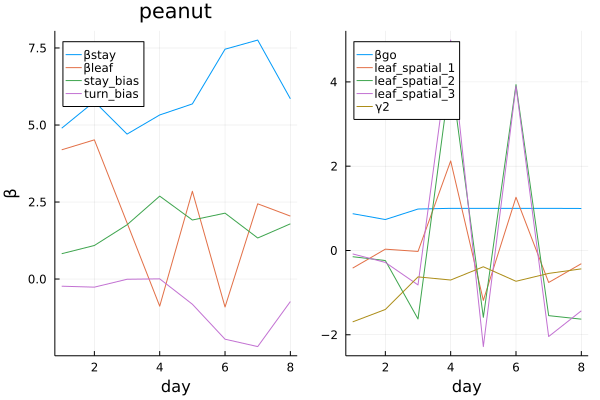

In [22]:
animal = "peanut"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

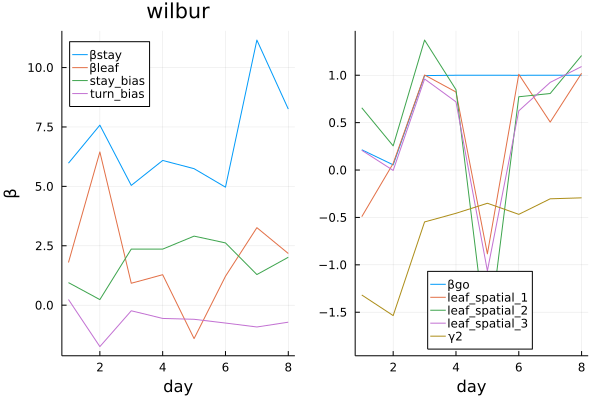

In [23]:
animal = "wilbur"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

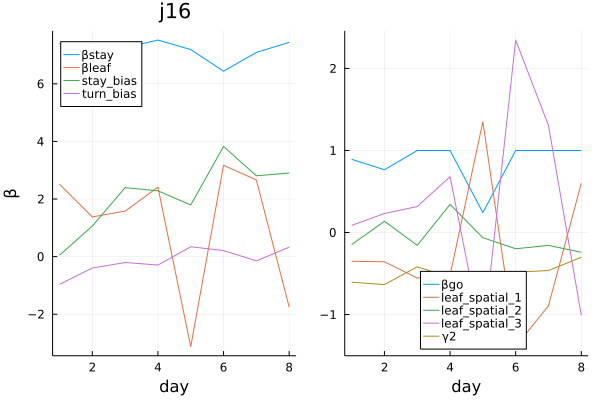

In [24]:
animal = "j16"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

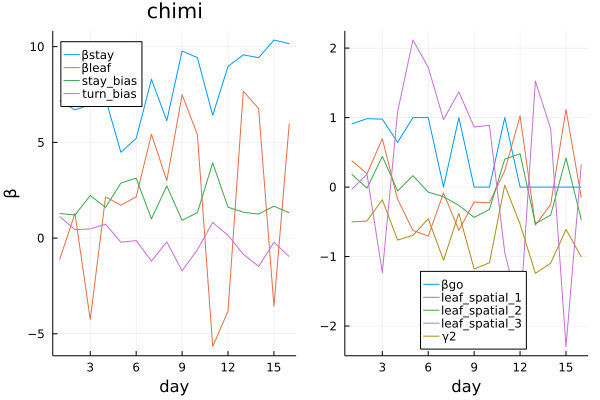

In [25]:
animal = "chimi"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=(0.4, 0.22))
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)

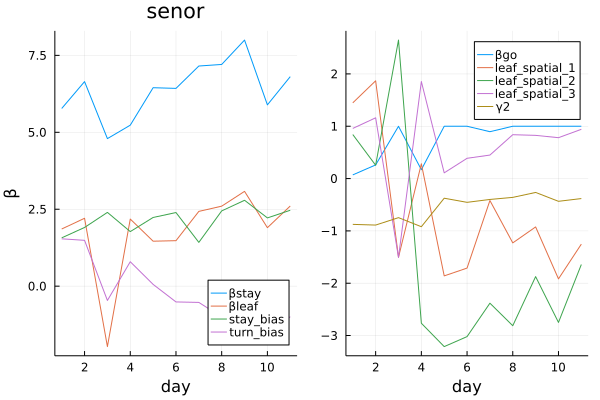

In [26]:
animal = "senor"
p1 = plot()
for i in 2:5
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:bottomright)
title!(animal)
xlabel!("day")
ylabel!("β")

p2 = plot()
plot!(0.5.+0.5.*erf.(results[animal].x[:, 1] ./ sqrt(2)), label=results[animal].varnames[1], legend=:topleft)
for i in 6:9
    plot!(results[animal].x[:, i], label=results[animal].varnames[i], legend=:topleft)
end
plot!(legend=:topright)
# title!("$(animal) (by day)")
xlabel!("day")
plot(p1, p2)